In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
import Xm

In [3]:
#xm=Xm.Xm(XmlFile='../testdata/FW.XML') # "C:\3S\Modelle\MVV_FW.XML"
xm=Xm.Xm(XmlFile=r'C:\3S\Modelle\MVV_FW.XML')

=== LFKT ===

In [4]:
xm.vLFKT.head(5)

,NAME,BESCHREIBUNG,LF,LF_min,LF_max,INTPOL,ZEITOPTION,pk_x
0,LfTh,Beschreibung Tabelle,1,1,1,0,0,4843828177877341965
1,LFKT,Lastgang f(LFT),1,1,1,0,0,5416134108033797245


In [5]:
xm.vLFKT.dtypes

NAME            object
BESCHREIBUNG    object
LF               int64
LF_min           int64
LF_max           int64
INTPOL          object
ZEITOPTION      object
pk_x            object
dtype: object

=== FWVB ===

In [6]:
xm.vFWVB[['VTYP','W0','LFK','TVL0','TRS0','W','INDTR','TRSK','NAME']].head(5)

,VTYP,W0,LFK,TVL0,TRS0,W,INDTR,TRSK,NAME
0,14,28.3694,1,130,60,28.3694,1,60,LfTh
1,14,11.0988,1,130,60,11.0988,1,60,LfTh
2,14,10.1879,1,130,60,10.1879,1,60,LfTh
3,14,14.5338,1,130,60,14.5338,1,60,LfTh
4,14,27.2216,1,130,60,27.2216,1,60,LfTh


In [7]:
xm.vFWVB[['VTYP','W0','LFK','TVL0','TRS0','W','INDTR','TRSK','NAME']].dtypes

VTYP       int64
W0       float64
LFK        int64
TVL0       int64
TRS0       int64
W        float64
INDTR      int64
TRSK       int64
NAME      object
dtype: object

In [8]:
#%matplotlib inline
import matplotlib.pyplot as plt

In [9]:
plt.close('all')
plt.figure()

In [10]:
vFWVB_h=xm.vFWVB[['W0']]

In [11]:
vFWVB_h.dtypes

W0    float64
dtype: object

In [12]:
vFWVB_h.plot.hist(bins=10
                  ,range=(0,240)
                 )

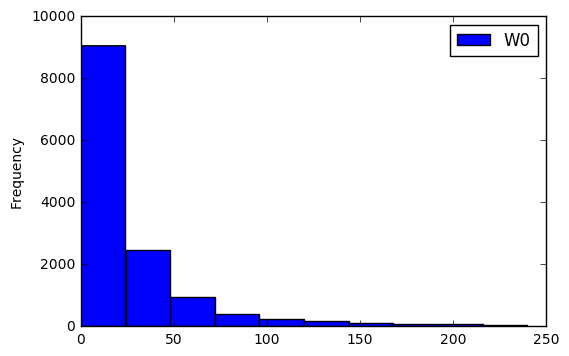

In [13]:
plt.show()

In [14]:
vFWVB_h.count()

W0    13930
dtype: int64

In [15]:
vFWVB_h['W0'].sum()

909471.3186699954

In [16]:
vFWVB_h['W0'].mean()

65.28868045010735

In [17]:
vFWVB_h['W0'].sum()/vFWVB_h['W0'].count()

65.28868045010735

In [18]:
vFWVB_h['W0'].median()

14.9894

In [19]:
binEdgeUpTo=math.ceil(vFWVB_h['W0'].mean())
print(binEdgeUpTo)

66


In [20]:
numOfBinsUpTo=10

In [21]:
binSpanUpto=math.floor(binEdgeUpTo/numOfBinsUpTo)
print(binSpanUpto)

6


In [22]:
rangeUpTo=range(0,binEdgeUpTo,binSpanUpto) 
edgesUpTo=[i for i in rangeUpTo]
#edgesUpTo.append(65)
print(edgesUpTo) #[[

[0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60]


In [23]:
labelsUpTo = [ "{0} - {1}".format(i, i + binSpanUpto-1 ) for i in rangeUpTo]
print(labelsUpTo)

['0 - 5', '6 - 11', '12 - 17', '18 - 23', '24 - 29', '30 - 35', '36 - 41', '42 - 47', '48 - 53', '54 - 59', '60 - 65']


In [24]:
plt.close('all')
plt.figure()

In [25]:
ax=vFWVB_h.plot.hist(x=vFWVB_h['W0'],bins=edgesUpTo
         #,range=(edgesUpTo[0],edgesUpTo[-1]+binSpanUpto)
         ,label=labelsUpTo
        # ,cumulative=True
        )

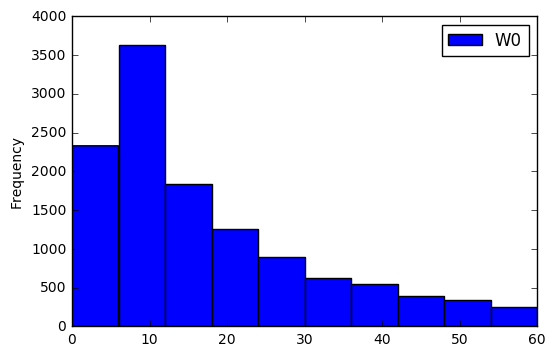

In [26]:
plt.show()

In [27]:
plt.close('all')
plt.figure()
ax=plt.subplot() #ax=plt.gca()

In [28]:
counts, bins, patches = ax.hist(x=vFWVB_h['W0']
                                 ,bins=edgesUpTo
         #,range=(edgesUpTo[0],edgesUpTo[-1]+binSpanUpto)
         ,label=labelsUpTo
        # ,cumulative=True
        )    

In [29]:
print(counts)

[ 2331.  3637.  1834.  1251.   901.   627.   549.   389.   343.   248.]


In [30]:
vFWVB_h[(vFWVB_h['W0']>=edgesUpTo[0]) & (vFWVB_h['W0']<edgesUpTo[1])].count()

W0    2331
dtype: int64

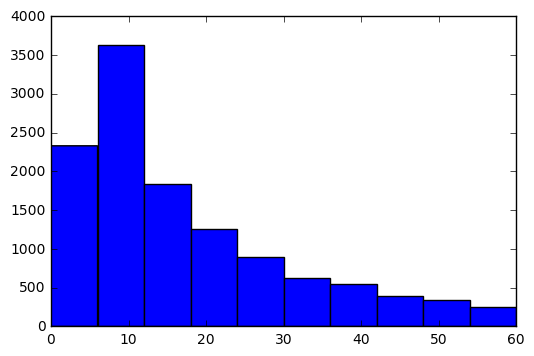

In [31]:
plt.show()

In [32]:
plt.close('all')
plt.figure()
ax=plt.subplot() #ax=plt.gca()

In [33]:
edgesUpTo=[0, 0.0001, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60]

In [34]:
labelsUpTo=['=0', '>0 - 5', '6 - 11', '12 - 17', '18 - 23', '24 - 29', '30 - 35', '36 - 41', '42 - 47', '48 - 53', '54 - 59', '60 - 65']

In [35]:
counts, bins, patches = ax.hist(x=vFWVB_h['W0']
                                 ,bins=edgesUpTo
         #,range=(edgesUpTo[0],edgesUpTo[-1]+binSpanUpto)
         ,label=labelsUpTo
        # ,cumulative=True
        )    

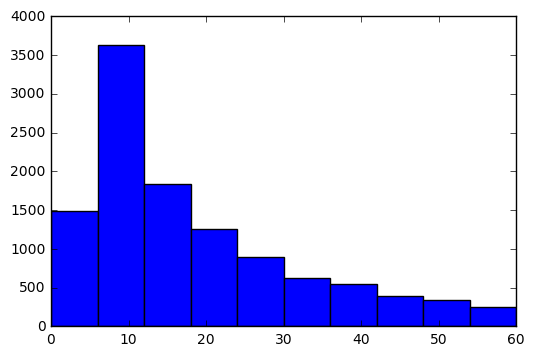

In [36]:
plt.show()

In [37]:
print(counts)

[  845.  1486.  3637.  1834.  1251.   901.   627.   549.   389.   343.
   248.]


In [107]:
vVKNO=pd.merge(xm.dataFrames['VKNO'],xm.dataFrames['CONT'],left_on='fkCONT',right_on='pk')
vVKNO=pd.merge(vVKNO,xm.dataFrames['KNOT'],left_on='fkKNOT',right_on='pk')
#vVKNO=pd.merge(vVKNO,xm.dataFrames['KNOT_BZ'],left_on='fkKNO',right_on='pk')


In [103]:
vVKNO.dtypes

DELETED_x       object
DISPLAYMODE     object
POINTINSERTX    object
POINTINSERTY    object
POSNAME         object
SELECT1_x       object
SHOWNAME        object
SYMBOLFACT      object
fkCONT_x        object
fkDE_x          object
fkKNOT          object
pk_x            object
rk_x            object
DELETED_y       object
FONT            object
GEOM            object
GRAF            object
ID              object
IDPARENT        object
LFDNR           object
NAME_x          object
SELECT1_y       object
fkDE_y          object
pk_y            object
rk_y            object
rkPARENT        object
tk_x            object
BESCHREIBUNG    object
DELETED         object
IDREFERENZ      object
IPLANUNG        object
KENNUNG         object
KTYP            object
KVR             object
LFAKT           object
NAME_y          object
QM_EIN          object
SELECT1         object
XKOR            object
YKOR            object
ZKOR            object
fk2LKNOT        object
fkCONT_y        object
fkDE       

In [108]:
vVKNO=vVKNO[[
       'NAME_x'     
      ,'NAME_y'     
      ,'KTYP'
      ,'pk','pk_y'
      ,'LFAKT','QM_EIN'  
    ]]
vVKNO=vVKNO.rename(columns={'NAME_x':'CONT','NAME_y':'NAME','pk':'pkKNOT','pk_y':'pkCONT'})

In [109]:
vVKNO.head()

,CONT,NAME,KTYP,pkKNOT,pkCONT,LFAKT,QM_EIN
0,MSH/PSE,K40086-A,QVAR,5498452708549742602,5038168934032900013,1,0
1,MSH/PSE,K40090-A,QKON,4907656556172397386,5038168934032900013,1,0
2,MSH/PSE,K40100-A,QKON,5276360638818671732,5038168934032900013,1,0
3,Rohrhof,K35322-A,QVAR,4981782902913107818,5090451068169492361,1,0
4,Rohrhof,K35334-A,QVAR,5042634543301781082,5090451068169492361,1,0


In [89]:
vVKNO['pk_x'].count()

61

In [87]:
vVKNO['pk_x'].count()

61

In [80]:
vKNOT=pd.merge(xm.dataFrames['KNOT'],xm.dataFrames['KNOT_BZ'],left_on='pk',right_on='fk')
vKNOT=pd.merge(vKNOT,xm.dataFrames['CONT'],left_on='fkCONT',right_on='pk')
#vKNOT=pd.merge(vKNOT,xm.dataFrames['PZON'],left_on='fkPZON',right_on='pk',how='left')
#vKNOT=pd.merge(vKNOT,xm.dataFrames['FSTF'],left_on='fkFSTF',right_on='pk',how='left')
#vKNOT=pd.merge(vKNOT,xm.dataFrames['STOF'],left_on='fkSTOF',right_on='pk',how='left')
#vKNOT=pd.merge(vKNOT,xm.dataFrames['UTMP'],left_on='fkUTMP',right_on='pk',how='left')

In [81]:
vKNOT.columns

Index(['BESCHREIBUNG', 'DELETED_x', 'IDREFERENZ', 'IPLANUNG', 'KENNUNG',
       'KTYP', 'KVR', 'LFAKT', 'NAME_x', 'QM_EIN', 'SELECT1_x', 'XKOR', 'YKOR',
       'ZKOR', 'fk2LKNOT', 'fkCONT', 'fkDE_x', 'fkFQPS', 'fkFSTF', 'fkHYDR',
       'fkPZON', 'fkUTMP', 'pk_x', 'rk_x', 'tk_x', 'DRAKONZ', 'GRAF_x',
       'PH_EIN', 'PH_MIN', 'TE', 'TM', 'fk', 'fkDE_y', 'fkLFKT', 'fkPVAR',
       'fkQVAR', 'pk_y', 'DELETED_y', 'FONT', 'GEOM', 'GRAF_y', 'ID',
       'IDPARENT', 'LFDNR', 'NAME_y', 'SELECT1_y', 'fkDE', 'pk', 'rk_y',
       'rkPARENT', 'tk_y'],
      dtype='object')

In [83]:
vKNOT=vKNOT[[
        'NAME_x'
       ,'BESCHREIBUNG','IDREFERENZ'
       ,'NAME_y'
       ,'KTYP'
       ,'LFAKT','QM_EIN'
       ,'KVR' 
       ,'TE','TM' 
       ,'XKOR','YKOR','ZKOR'
    ]]

In [84]:
vKNOT['NAME_x'].count()

81835

In [60]:
vKNOT.dtypes

BESCHREIBUNG    object
DELETED_x       object
IDREFERENZ      object
IPLANUNG        object
KENNUNG         object
KTYP            object
KVR             object
LFAKT           object
NAME_x          object
QM_EIN          object
SELECT1_x       object
XKOR            object
YKOR            object
ZKOR            object
fk2LKNOT        object
fkCONT          object
fkDE_x          object
fkFQPS          object
fkFSTF          object
fkHYDR          object
fkPZON          object
fkUTMP          object
pk_x            object
rk_x            object
tk_x            object
DRAKONZ         object
GRAF_x          object
PH_EIN          object
PH_MIN          object
TE              object
                 ...  
PKMAXBH         object
PKMAXRA         object
PKMINBH         object
PKMINRA         object
SELECT1         object
fkDE_y          object
pk_y            object
rk_x            object
tk_x            object
CP              object
DRACOEFFA       object
DRACOEFFB       object
DRACOEFFC  

In [55]:
vKNOT.head(5)

,BESCHREIBUNG,DELETED_x,IDREFERENZ,IPLANUNG,KENNUNG,KTYP,KVR,LFAKT,NAME_x,QM_EIN,...,NAME_y,PREF,RHONORM,TREF,fkDE,fkGMIX,fkSTOF,pk,rk_y,tk_y
0,"Q = 0 m3/h; P = 8,9659 bar; H = 191,491 m",0,00270000000ccd6e,1,0,QKON,1,1,K25826,0,...,Standard,1.01325,999.84,0,5335468155685356318,-1,5747535079283781385,5492567108573712160,5492567108573712160,5492567108573712160
1,"Q = 0 m3/h; P = 2,2996 bar; H = 116,62 m",0,00270000000a6d94,1,0,QKON,2,1,K19343,0,...,Standard,1.01325,999.84,0,5335468155685356318,-1,5747535079283781385,5492567108573712160,5492567108573712160,5492567108573712160
2,"Q = 0 m3/h; P = 2,1035 bar; H = 120,485 m",0,002700010000cfb2,1,0,QKON,2,1,K60374,0,...,Standard,1.01325,999.84,0,5335468155685356318,-1,5747535079283781385,5492567108573712160,5492567108573712160,5492567108573712160
3,"Q = 0 m3/h; P = 6,4215 bar; H = 169,506 m",0,0027000100032cd4,1,0,QKON,1,1,K69824,0,...,Standard,1.01325,999.84,0,5335468155685356318,-1,5747535079283781385,5492567108573712160,5492567108573712160,5492567108573712160
4,"Q = 0 m3/h; P = 8,7069 bar; H = 188,21 m",0,KNO001674588B5B5FD741,1,0,QKON,1,1,K28251,0,...,Standard,1.01325,999.84,0,5335468155685356318,-1,5747535079283781385,5492567108573712160,5492567108573712160,5492567108573712160


In [57]:
xm.dataFrames['FSTF'].dtypes

CP           object
DRACOEFFA    object
DRACOEFFB    object
DRACOEFFC    object
DYNVISKO     object
EPS          object
GKOMP1       object
GKOMP2       object
INDSTF       object
ISOTHERM     object
K            object
NAME         object
PREF         object
RHONORM      object
TREF         object
fkDE         object
fkGMIX       object
fkSTOF       object
pk           object
rk           object
tk           object
dtype: object